# Implementing Validation

## Dependencies & Utilities

In [11]:
import os
# SET THE FALLBACK VARIABLE BEFORE TORCH IS IMPORTED
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1' #I need this to use the mac GPU (some operations are not supported on MPS)

In [12]:
# general
import random
import numpy as np
import matplotlib.pyplot as plt

# huggingface
from transformers import AutoModel
from datasets import load_dataset

# qdrant
from qdrant_client import QdrantClient
from qdrant_client import models

# torch
import torch
from torch import optim
from torch.utils.data import DataLoader

# pytorch metric learning
from pytorch_metric_learning import distances, losses, miners, reducers

# torchvision
import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils

# PIL
from PIL import Image
import PIL.ImageOps    

## Data 

###  Data loading

In [13]:
from src.dataset import CustomDataset, NestedFolderLoader

# Load the complete dataset
root_dir = './data/tilda-data' 

label_map = {
    "good": 0,
    "hole": 1,
    "objects": 2,
    "oil spot": 3,
    "thread error": 4
}

nested_loader = NestedFolderLoader()
plain_transform = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor()])

complete_dataset = CustomDataset(transform=plain_transform, label_map=label_map)
complete_dataset.add_data(nested_loader,root_dir, filter_label_names=['good'])

#splitting the dataset
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(complete_dataset, [0.7,0.2, 0.1])

In [14]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

torch.Size([32, 3, 256, 256])
torch.Size([32])
Label 3


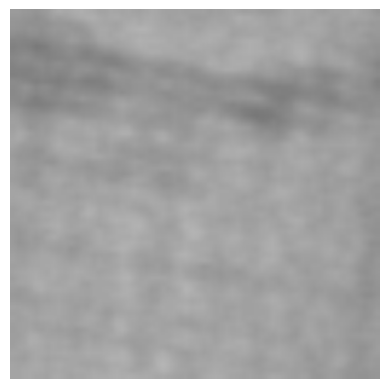

In [17]:
dataiter = iter(train_dataloader)

example_batch = next(dataiter)

print(example_batch[0].shape) # batched img 
print(example_batch[1].shape) # batched labels


inbatch_index = 6
print("Label", example_batch[1][inbatch_index].item())
plt.axis("off")
plt.imshow(example_batch[0][inbatch_index].numpy().transpose(1, 2, 0))

## Model training

In [18]:
from src.cnn import ViTNetwork

# Define device (will still try to use MPS first)
if torch.cuda.is_available():
    device_name = 'cuda'
elif torch.backends.mps.is_available():
    # Check for Metal Performance Shaders (MPS) on Apple Silicon GPUs
    # is_available() checks if MPS is available for use.
    device_name = 'mps'
else:
    # Fallback to CPU if neither CUDA nor MPS is available
    device_name = 'cpu'

# Create the torch.device object
device = torch.device(device_name)
print(f"Using device: {device}")

# Instantiate the base model and the build the siamese network on top of it
base_model = AutoModel.from_pretrained("facebook/dinov2-base").to(device)
net = ViTNetwork(base_model, 10)
net = net.to(device)

# Define parameters
learning_rate = 0.0001


# Define the Loss Function (TripletMarginLoss is standard for triplets)
loss_func = losses.ArcFaceLoss(num_classes=6,
                               embedding_size=1536,
                               margin=28.6,
                               scale=64.0).to(device)


# 5. Define the Optimizer
optimizer = optim.Adam([
    {'params': net.parameters()},
    {'params': loss_func.parameters()} # Add loss function parameters
], lr=learning_rate)

Using device: mps
Unfreezing layer: encoder.layer.11.layer_scale1.lambda1
Unfreezing layer: encoder.layer.11.norm2.weight
Unfreezing layer: encoder.layer.11.norm2.bias
Unfreezing layer: encoder.layer.11.mlp.fc1.weight
Unfreezing layer: encoder.layer.11.mlp.fc1.bias
Unfreezing layer: encoder.layer.11.mlp.fc2.weight
Unfreezing layer: encoder.layer.11.mlp.fc2.bias
Unfreezing layer: encoder.layer.11.layer_scale2.lambda1
Unfreezing layer: layernorm.weight
Unfreezing layer: layernorm.bias


In [19]:
from src.trainer import Trainer, TrainerParams

training_params = TrainerParams(
    epochs=70,
    patience=10,
    device=device,
    save_dir='./models',
    save_prefix='ViT-tilda-finetuning',
    )

trainer = Trainer(model = net,
                  loss = loss_func,
                  optimizer = optimizer,
                  train_dataloader= train_dataloader,
                  val_dataloader= val_dataloader,
                  params=training_params
)
trainer.run()

Start training...
Epoch 1/70:



Training: 54it [03:35,  4.00s/it]


1-epoch train loss -> 29.480


Validation: 16it [00:49,  3.09s/it]


1-epoch validation loss -> 27.147
Best model saved with loss: 27.147
Epoch 2/70:



...

46-epoch validation loss -> 11.451
No improvement for 9 epoch(s).
Epoch 47/70:



Training: 54it [04:50,  5.37s/it]


47-epoch train loss -> 6.684


Validation: 16it [00:42,  2.68s/it]

47-epoch validation loss -> 15.374
No improvement for 10 epoch(s).
Early stopping triggered.


In [ ]:
import matplotlib.pyplot as plt

def plot_losses(trainer):
    plt.figure(figsize=(10, 6))
    plt.plot(trainer.tr_losses, label="Training Loss")
    plt.plot(trainer.val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
plot_losses(trainer)

In [52]:
net.load_state_dict(torch.load('./models/ViT-tilda-finetuning_best_model.pth'))

<All keys matched successfully>

## 4. Embeddings

Let's create a function with the process we just walked through above and map it to our dataset to get an
embedding vector for each image.

In [53]:
from tqdm import tqdm

def get_embeddings(model, dataloader,device):
    model.eval()
    all_embeddings = []
    all_labels = []
    all_image_paths = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Extracting embeddings"):
            images, labels = batch
    
            images = images.to(device)
            model.to(device)
            embeddings = model(images).cpu().numpy()

            all_embeddings.append(embeddings)
            all_labels.extend(labels)
    
    all_embeddings = np.concatenate(all_embeddings, axis=0)
    return {
        'embeddings': all_embeddings,
        'labels': np.array(all_labels),
    }

In [54]:
embedded_data = get_embeddings(model=net,
                               dataloader=test_dataloader,
                               device=device)

Extracting embeddings: 100%|██████████| 8/8 [00:19<00:00,  2.48s/it]


#### Visualize

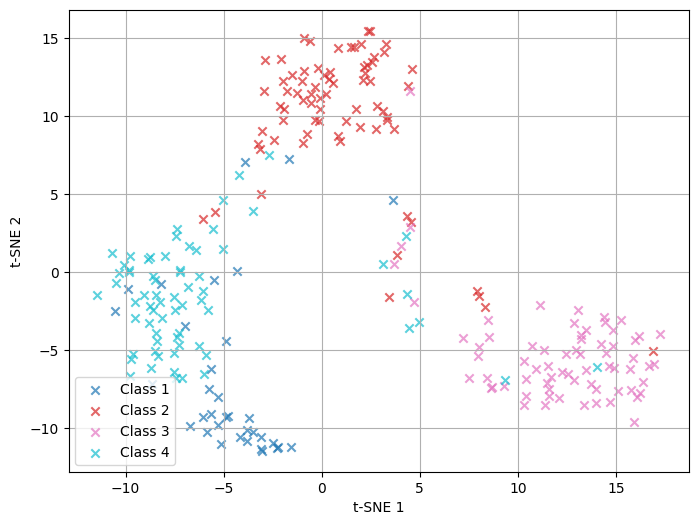

In [55]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)

embeddings = np.array(embedded_data['embeddings'])

y_train = np.array(embedded_data['labels'])

unique_labels = np.unique(y_train)
cmap = plt.get_cmap('tab10', len(unique_labels)) # Get a colormap


tsne_transformed_embeddings = tsne.fit_transform(embeddings)
plt.figure(figsize=(8, 6))
for i, label in enumerate(unique_labels):
    class_color = cmap(i /(len(unique_labels)-1)) # Assign color based on class index
    idx = y_train == label
    plt.scatter(tsne_transformed_embeddings[idx, 0], tsne_transformed_embeddings[idx, 1], 
                label=f"Class {label}", alpha=0.7, marker='x',color=class_color)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.grid(True)
plt.legend(loc='lower left')
plt.show()